## Zadanie domowe: BBHE i DSIHE

W klasycznym wyrównywaniu histogramu HE  po wykonaniu operacji jasność obrazu ulega zmianie.
Dało się to zaobserwować podczas przeprowadzonych eksperymentów.
Jeśli nie to należy uruchomić skrypt z sekcji A i zwrócić na to uwagę.
Średnia jasność dąży do środkowego poziomu szarości.
Jest to wada i dlatego klasyczne HE ma ograniczone zastosowanie.

Powstało sporo metod, które eliminują to niekorzystne zjawisko.
Najprostsze z nich polegają na dekompozycji obrazu wejściowego na dwa podobrazy (wg. pewnego kryterium).
Następnie operacja HE wykonywana jest dla tych podobrazów.

Dwie znane z literatury metody to:
- Bi-Histogram Equalization
- DSIHE - Dualistic Sub-Image Histogram Equalization

W metodzie BBHE za kryterium podziału przyjmuje się średnią jasność w obrazie.
W DSIHE obraz dzieli się na dwa podobrazy o takiej samej liczbie pikseli (jaśniejszych i ciemniejszych).

W ramach zadania należy zaimplementować wybraną metodę: BBHE lub DSIHE (ew. obie).

1. Wczytaj obraz *jet.bmp* i wylicz jego histogram.
2. W kolejnym kroku należy wyznaczyć próg podziału obrazu na dwa podobrazy (*lm*).
3. Dla BBHE wyznacz średnią jasność obrazu. Dla DSIHE można wykorzystać histogram skumulowany.
Należy znaleźć poziom jasności który znajduje się "w połowie" histogramu skumulowanego.
W tym celu warto stworzyć tablicę, zawierającą moduł histogramu skumulowanego pomniejszonego o połowę liczby pikseli.
Następnie znaleźć minimum - `np.argmin`.
4. Dalej należy podzielić histogram oryginalnego obrazu na dwa histogramy *H1* i *H2*.
Dla każdego z nich wyliczyć histogram skumulowany ($C_1$ i $C_2$) i wykonać normalizację.
Normalizacja polega na podzieleniu każdego histogramu przez jego największy element.
5. Na podstawie histogramów skumulowanych należy stworzyć przekształcenie LUT.
Należy tak przeskalować $C_1$ i $C_2$, aby uzyskać jednorodne przekształcenie.
Tablicę $C_1$ wystarczy pomnożyć przez próg podziału.
Tablicę $C_2$ należy przeskalować do przedziału: $<lm+1; 255>$, gdzie $lm$ jest progiem podziału.<br>
$C_{1n} = (lm)*C1;$<br>
$C_{2n} = lm+1 + (255-lm-1)*C2;$<br>
Następnie dwie części tablicy przekodowań należy połączyć.
6. Na koniec należy wykonać operację LUT i wyświetlić wynik wyrównywania histogramu.
Porównaj wynik operacji BBHE lub DSIHE z klasycznym HE.

In [ ]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/03_Histogram/'
fileName = 'jet.bmp'
if not os.path.exists(fileName) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

Próg BBHE: 178, próg DSIHE: 199


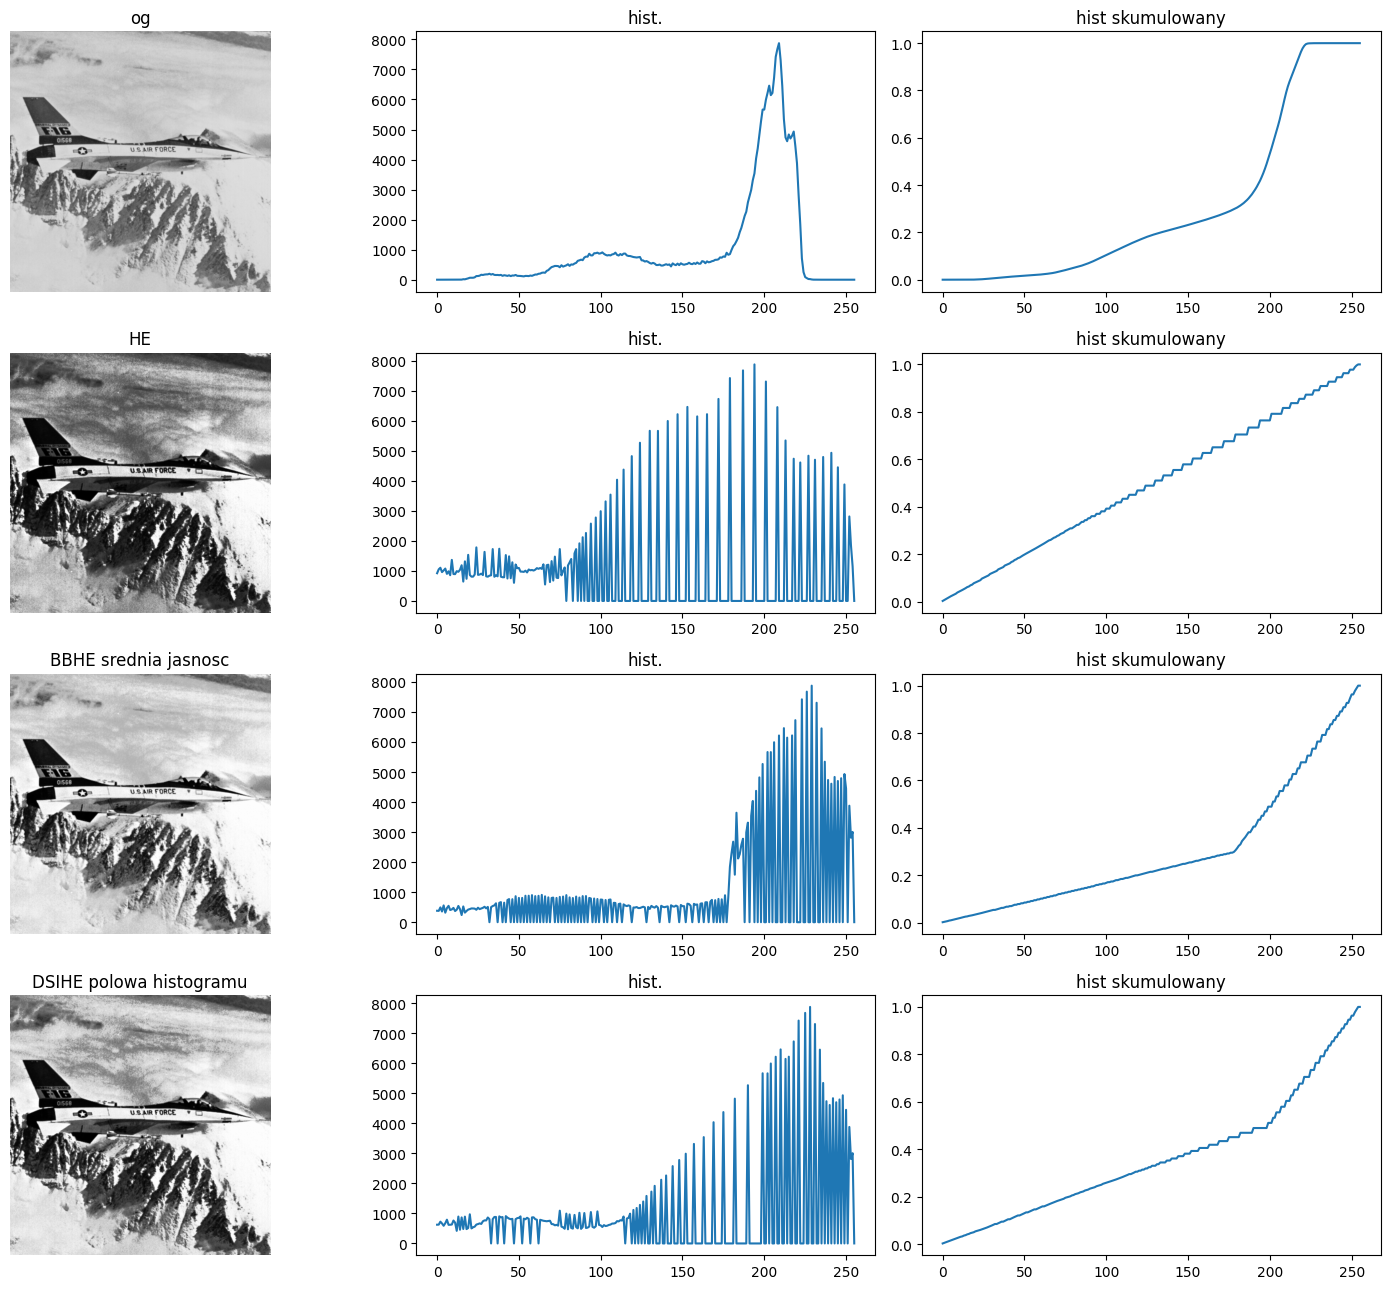

In [ ]:
I = cv2.imread('jet.bmp', cv2.IMREAD_GRAYSCALE)


H = cv2.calcHist([I], [0], None, [256], [0,256]).ravel()
C = H.cumsum()

# srednia
lm_BBHE = int(np.mean(I))

# DSIHE
half_pixels = C[-1] / 2
lm_DSIHE = np.argmin(np.abs(C - half_pixels))

print(f"Próg BBHE: {lm_BBHE}, próg DSIHE: {lm_DSIHE}")

def create_LUT(H, lm, method='BBHE'):
    H1 = H[:lm+1]
    H2 = H[lm+1:]

    C1 = np.cumsum(H1)
    C2 = np.cumsum(H2)

    C1 = C1 / C1[-1]
    C2 = C2 / C2[-1]

    C1n = (lm) * C1
    C2n = lm + 1 + (255 - lm - 1) * C2

    LUT = np.concatenate((C1n, C2n)).astype('uint8')
    return LUT

LUT_BBHE = create_LUT(H, lm_BBHE)
LUT_DSIHE = create_LUT(H, lm_DSIHE)

I_BBHE = LUT_BBHE[I]
I_DSIHE = LUT_DSIHE[I]

C_masked = np.ma.masked_equal(C, 0)
LUT_HE = np.ma.filled((C_masked - C_masked.min()) * 255 / (C_masked.max() - C_masked.min()), 0).astype('uint8')
I_HE = LUT_HE[I]

fig, axs = plt.subplots(4, 3, figsize=(15, 13))

images = [I, I_HE, I_BBHE, I_DSIHE]
titles = [
    'og',
    'HE',
    'BBHE srednia jasnosc',
    'DSIHE polowa histogramu'
]

for i, (img, title) in enumerate(zip(images, titles)):
    row = i
    axs[row, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[row, 0].set_title(title)
    axs[row, 0].axis('off')

    # Histogram
    H_img = cv2.calcHist([img], [0], None, [256], [0,256])
    axs[row, 1].plot(H_img)
    axs[row, 1].set_title('hist.')

    # Histogram skumulowany
    C_img = H_img.cumsum()
    axs[row, 2].plot(C_img / C_img.max())
    axs[row, 2].set_title('hist skumulowany')

plt.tight_layout()
plt.show()